# GO Analysis for WGCNA
## Phase 2 

Gene ontology of modules from [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/wgcna_p1.ipynb) using the [new reference genome](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/). Following [Gurr code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/GO_Analysis_WGCNA_all.R)

Since we don't have log fold change (because we aren't looking at differential expression), we can only do an over-representation analysis (ORA) - provide a gene list of interest (genes in a significantly correlated module) and a universal gene list (after filtering for wgcna - so *not* all genes in the CV genome, but rather what went in as input to wgcna)

## 0. load libraries

In [2]:
library(tidyverse)
library(goseq)
library(reshape2)
library(Rmisc)
library(ggpubr)
library(gridExtra)
library(forcats)
library(zoo)
library(ComplexHeatmap)
library(GO.db)
library(GSEABase)
library(clusterProfiler)

## 1. load data
WGCNA module membership, module colors, and goslim_generic.obo

#### A. gene annotation to GO.term - long format
matches GO terms to *C. virginica* genes - one GO term per row (so genes are duplicated among rows)

In [3]:
annot <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'

# One row for each gene and GO.term
term2gene <- annot %>%
  separate_rows(GO.terms, sep = ";") %>% # one row for each GO.term
  filter(!is.na(GO.terms) & GO.terms != "") %>% # remove genes without GO terms
  dplyr::select(term = GO.terms, gene = Gene) # rename columns for GO 

# 

head(term2gene)

term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


this becomes input for `enricher` down below

get term names for GO IDs

In [4]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


#### B. GOslim data

GO Slim - higher level of GO used to summarize GO results into broader categories (the parent terms)

In [5]:
slim <- getOBOCollection("http://current.geneontology.org/ontology/subsets/goslim_generic.obo")
class(slim)

[1] "OBOCollection"
attr(,"package")
[1] "GSEABase"

In [6]:
# 1. Get the GO IDs
slim_ids <- ids(slim)

# 2. Get the IDs that belong to the generic subset
slim_ids <- ids(slim["goslim_generic" ])

# 3. Get the terms for those specific IDs
# use the GO.db package because it's much faster and more reliable for names
slim_terms <- Term(slim_ids)

# 4. Create lookup table 
slim_lookup <- data.frame(
  SlimID = names(slim_terms), # parent ID
  GOSlim_Bin = as.character(slim_terms), # biological term
  stringsAsFactors = FALSE
)

head(slim_lookup)

,SlimID,GOSlim_Bin
,<chr>,<chr>
1,GO:0000228,nuclear chromosome
2,GO:0000278,mitotic cell cycle
3,GO:0000910,cytokinesis
4,GO:0001618,virus receptor activity
5,GO:0002181,cytoplasmic translation
6,GO:0002376,immune system process


this table can be used to assign GO terms to broader categories - however, this table only contains parent terms (SlimID), so cannot directly be merged with GO results - need to match the parent terms to the GO IDs

In [7]:
# 1. Get a list of all ancestors for every GO term in WGCNA results
# This creates a mapping of Specific_ID -> All_Ancestors
all_ancestors <- as.list(GOBPANCESTOR)

# lookup vector - parent GO terms
target_slim_ids <- unique(slim_lookup$SlimID)

# 2. make lookup function
find_slim_parent <- function(specific_id, slim_ids) {
  if (is.na(specific_id)) return(NA_character_) # if GO term isn't in ancestor lookup
  if (specific_id %in% slim_ids) return(specific_id) # if GO term is the parent term
  
  # Get ancestors from the GO.db object
  ancestors <- all_ancestors[[specific_id]]
  
  if (is.null(ancestors)) return(NA_character_) # if no ancestor term
  
  # Find which ancestors are in your Slim list
  match <- intersect(ancestors, slim_ids)
  
  if (length(match) == 0) return(NA_character_)
  return(as.character(match[1])) 
}


#### C. Gene info
read in gene info from [wgcna_p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/wgcna/wgcna_p2.ipynb)

contains the gene name, matching GO terms, module color, gene significance (GS) for every treatment, and module membership (MM) for each module

In [8]:
geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p1.wgcna_GeneInfo.csv') 
head(geneInfo) 

,Gene,GO.terms,ModuleColor,GS.ambient,GS.normoxic,phase1_treatment.GS.both,phase1_treatment.GS.control,phase1_treatment.GS.hypoxic,phase1_treatment.GS.warm,p.GS.ambient,⋯,MMgrey60,MMskyblue,MMlightgreen,MMbrown,MMdarkgreen,MMwhite,MMpurple,MMyellow,MMdarkgrey,MMsalmon
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,magenta,-0.35380574,0.12117253,0.01413832,-0.24021041,-0.15227705,0.39343144,0.1259224,⋯,0.03234708,0.21072791,0.10579276,-0.253432155,0.059511636,-0.03521488,-0.24476817,-0.13443160,0.07193762,0.04142548
2,LOC111099040,GO:0005515;GO:0007169;GO:0035556,grey60,0.38543189,0.22119072,-0.48185106,0.23796773,0.19098616,0.00228741,0.0932918,⋯,0.49605329,0.04238787,-0.15141525,0.130092136,0.123516087,-0.12941687,-0.12077803,-0.28899429,-0.20576952,-0.09785979
3,LOC111099041,GO:0016020;GO:0022857;GO:0055085,pink,0.04271455,-0.31134169,0.11758188,-0.18899321,0.24908689,-0.15769276,0.8580899,⋯,-0.01006947,-0.03562632,-0.28534030,-0.095151830,-0.171128226,-0.43014690,-0.04595866,-0.21603454,0.11164322,0.25712188
4,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,black,0.29992706,-0.06425273,-0.22576188,0.05879171,0.28237065,-0.13604006,0.1988723,⋯,0.17477011,0.23733611,0.15190315,-0.162191108,0.016913880,-0.19914462,0.36747715,0.31683154,-0.15683078,-0.03143776
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,grey60,0.14429745,-0.19812526,0.14214034,0.06563370,0.09632497,-0.29708878,0.5438798,⋯,0.54839515,0.10911711,-0.09058304,0.005681654,-0.005374575,-0.36051894,-0.04986036,-0.35245538,-0.43384568,-0.29787464
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,cyan,-0.33772029,0.42418002,-0.07947776,0.02448856,-0.41392732,0.46142948,0.1453172,⋯,-0.14412849,0.02832059,0.15737953,-0.084139786,0.150425993,-0.02658092,-0.22855601,-0.09548234,-0.41735822,-0.53034024


categorize gene info columns

In [9]:
# Get all column names once
all_cols <- names(geneInfo)

# 1. The 16 'Combo_treatments.GS' columns
combo_cols <- grep("^Combo_treatments\\.GS\\.", all_cols, value = TRUE)

# 2. Phase 1 & 2 Driver columns (Temp and DO)
p1_driver_cols <- grep("^phase1_(temp|DO)\\.GS\\.", all_cols, value = TRUE)
p2_driver_cols <- grep("^phase2_(temp|DO)\\.GS\\.", all_cols, value = TRUE)

# 3. Overall Phase Treatment columns
p1_overall_cols <- grep("^phase1_treatment\\.GS\\.", all_cols, value = TRUE)
p2_overall_cols <- grep("^phase2_treatment\\.GS\\.", all_cols, value = TRUE)

# 4. Module Membership (MM) colors
mm_cols <- grep("^MM", all_cols, value = TRUE)

#### Module membership
pull out just the genes, associated GO terms, and which module they're been assigned to

In [10]:
moduleMembership <-  geneInfo %>% dplyr::select(Gene, GO.terms, ModuleColor) # select for genes, GO.ids, modules
head(moduleMembership)

,Gene,GO.terms,ModuleColor
,<chr>,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,magenta
2,LOC111099040,GO:0005515;GO:0007169;GO:0035556,grey60
3,LOC111099041,GO:0016020;GO:0022857;GO:0055085,pink
4,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,black
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,grey60
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,cyan


#### D. universal list
this is the input gene list for wgcna before module assignment, but after gene filtering

In [17]:
universal_genes <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/wgcna/p1.wgcna_UniversalGeneList.csv')
colnames(universal_genes) <- 'gene'
head(universal_genes)

,gene
,<chr>
1,LOC144621260
2,LOC144621269
3,LOC111120925
4,LOC144621283
5,LOC144621276
6,LOC111115920


## 2. run GO enrichment
over-representation analysis

**input data:**
- universal_genes
- term2gene (matches gene LOC to GO term)
- term2name (matches GO term to GO description)
- geneInfo (output from WGCNA)

slim_lookup for matching parent GO terms to GO results

### lightyellow module
pos. corr. with shell growth

In [20]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

# lightyellow 
target_genes <- geneInfo %>%
  filter(ModuleColor == "lightyellow") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
lightyellow_res <- as.data.frame(ego_custom)
lightyellow_res

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no enriched GO terms

### greenyellow module
pos. corr. with shell growth

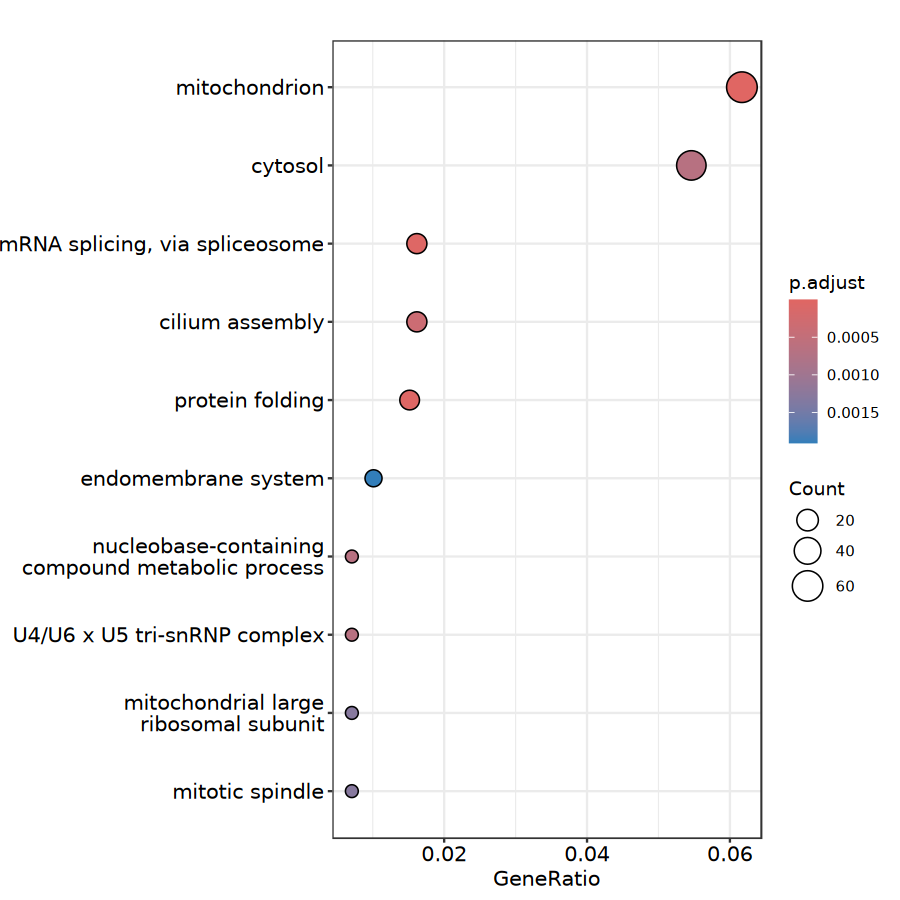

In [21]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "greenyellow") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
greenyellow_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

look for parent terms/bin GO terms to broader categories

In [22]:
greenyellow_mapped <- greenyellow_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
greenyellow_final <- greenyellow_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'greenyellow'")

head(greenyellow_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0005739,mitochondrion,61/989,232/9286,9.231462e-12,3.147929e-09,2.711135e-09,LOC111100670/LOC111104137/LOC111104154/LOC111104191/LOC111104253/LOC111104483/LOC111104702/LOC111105866/LOC111106365/LOC111107126/LOC111107699/LOC111113204/LOC111114229/LOC111116418/LOC111117758/LOC111117976/LOC111118028/LOC111118249/LOC111118461/LOC111118962/LOC111120825/LOC111120828/LOC111120899/LOC111121538/LOC111121564/LOC111121759/LOC111125126/LOC111125202/LOC111127785/LOC111127815/LOC111127947/LOC111128123/LOC111128302/LOC111128521/LOC111128646/LOC111129097/LOC111129859/LOC111129960/LOC111130026/LOC111130095/LOC111130179/LOC111130538/LOC111130608/LOC111130738/LOC111130742/LOC111132779/LOC111133074/LOC111133078/LOC111133426/LOC111133477/LOC111133507/LOC111134458/LOC111134852/LOC111135308/LOC111135530/LOC111135916/LOC111136154/LOC144620891/LOC144622705/LOC144622927/LOC144627595,61,GO:0005739,mitochondrion,'greenyellow'
GO:0000398,"mRNA splicing, via spliceosome",16/989,36/9286,2.257513e-07,3.849060e-05,3.314980e-05,LOC111104149/LOC111106006/LOC111106010/LOC111106208/LOC111111061/LOC111118582/LOC111119055/LOC111121238/LOC111129054/LOC111135499/LOC111136320/LOC111136408/LOC111138363/LOC111138391/LOC144618296/LOC144622290,16,GO:0016071,mRNA metabolic process,'greenyellow'
GO:0006457,protein folding,15/989,33/9286,3.775461e-07,4.291440e-05,3.695977e-05,LOC111106300/LOC111107136/LOC111114582/LOC111120649/LOC111120828/LOC111121532/LOC111125459/LOC111128545/LOC111128611/LOC111128632/LOC111128939/LOC111129850/LOC111130072/LOC111133727/LOC111134667,15,GO:0006457,protein folding,'greenyellow'
GO:0060271,cilium assembly,16/989,43/9286,3.978499e-06,3.391671e-04,2.921056e-04,LOC111105908/LOC111106953/LOC111107237/LOC111118542/LOC111118797/LOC111120826/LOC111121573/LOC111129512/LOC111130072/LOC111130439/LOC111134366/LOC111134972/LOC111135089/LOC111135793/LOC111136209/LOC111138025,16,GO:0044782,cilium organization,'greenyellow'
GO:0005829,cytosol,54/989,281/9286,1.032583e-05,6.664223e-04,5.739522e-04,LOC111103044/LOC111103864/LOC111103886/LOC111104191/LOC111105293/LOC111105636/LOC111106068/LOC111107093/LOC111110954/LOC111111015/LOC111112221/LOC111113059/LOC111113199/LOC111116740/LOC111118136/LOC111118247/LOC111118582/LOC111118918/LOC111118963/LOC111120899/LOC111121293/LOC111125457/LOC111127104/LOC111127241/LOC111127358/LOC111127391/LOC111127492/LOC111127774/LOC111128121/LOC111128253/LOC111128304/LOC111128611/LOC111129847/LOC111129850/LOC111129886/LOC111130366/LOC111130491/LOC111130537/LOC111132796/LOC111133013/LOC111133780/LOC111133890/LOC111135006/LOC111135530/LOC111136223/LOC111138068/LOC111138323/LOC144625404/LOC144625422/LOC144625455/LOC144626444/LOC144626796/LOC144626843/LOC144626856,54,GO:0005829,cytosol,'greenyellow'
GO:0006890,"retrograde vesicle-mediated transport, Golgi to endoplasmic reticulum",7/989,12/9286,7.442482e-05,2.307169e-03,1.987036e-03,LOC111105880/LOC111114496/LOC111125460/LOC111127011/LOC111132171/LOC111134608/LOC111134680,7,GO:0016192,vesicle-mediated transport,'greenyellow'


splicing!! that's exciting

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


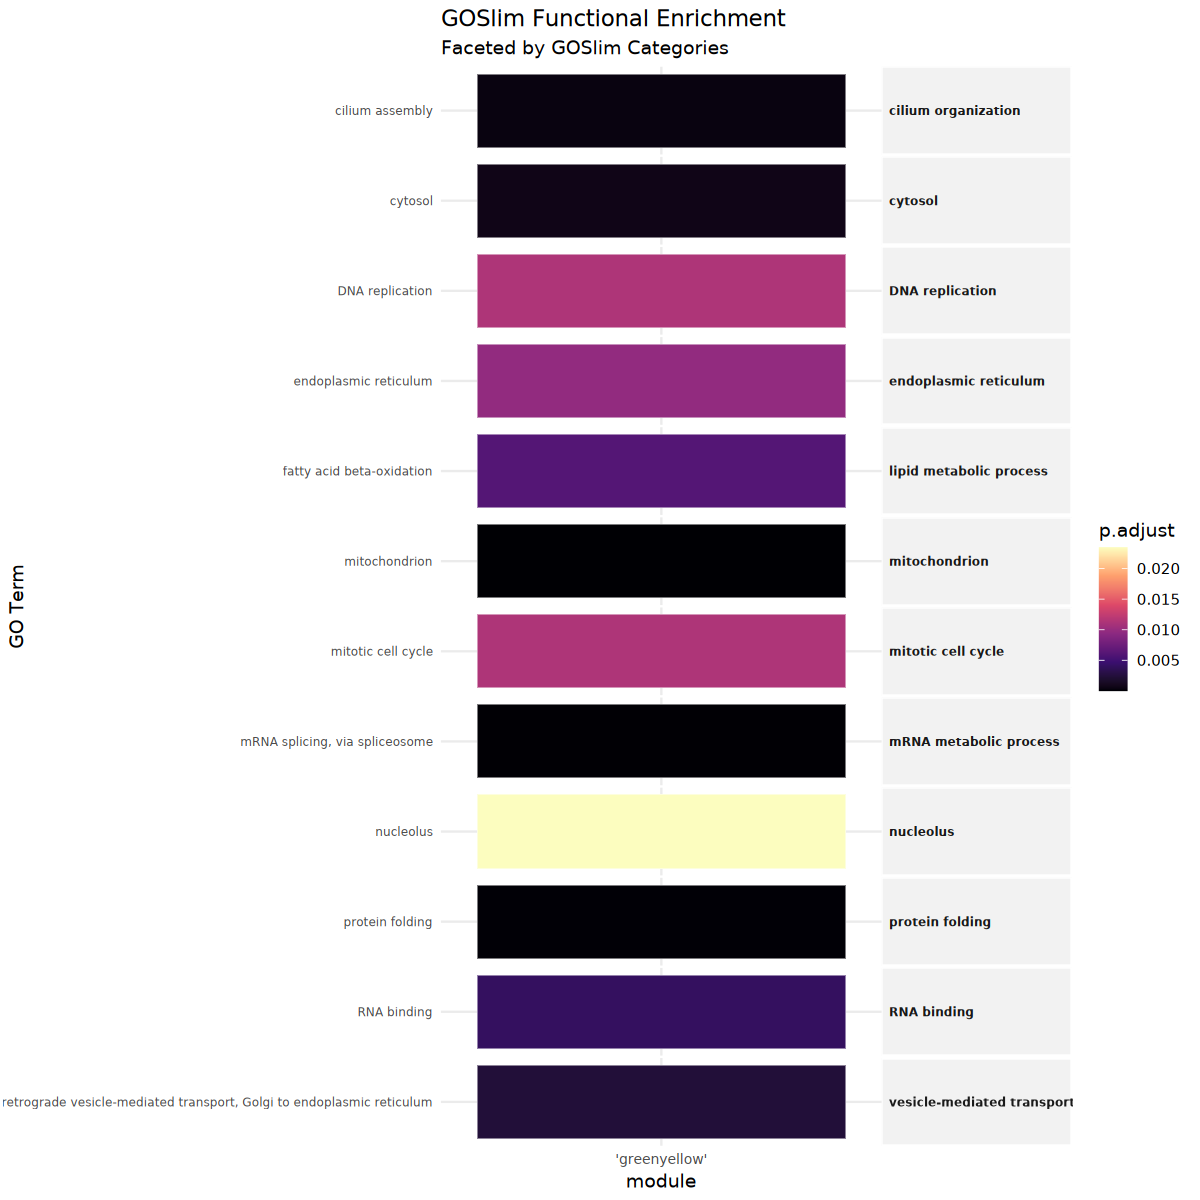

In [23]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(greenyellow_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

### cyan module
pos. corr. with shell growth

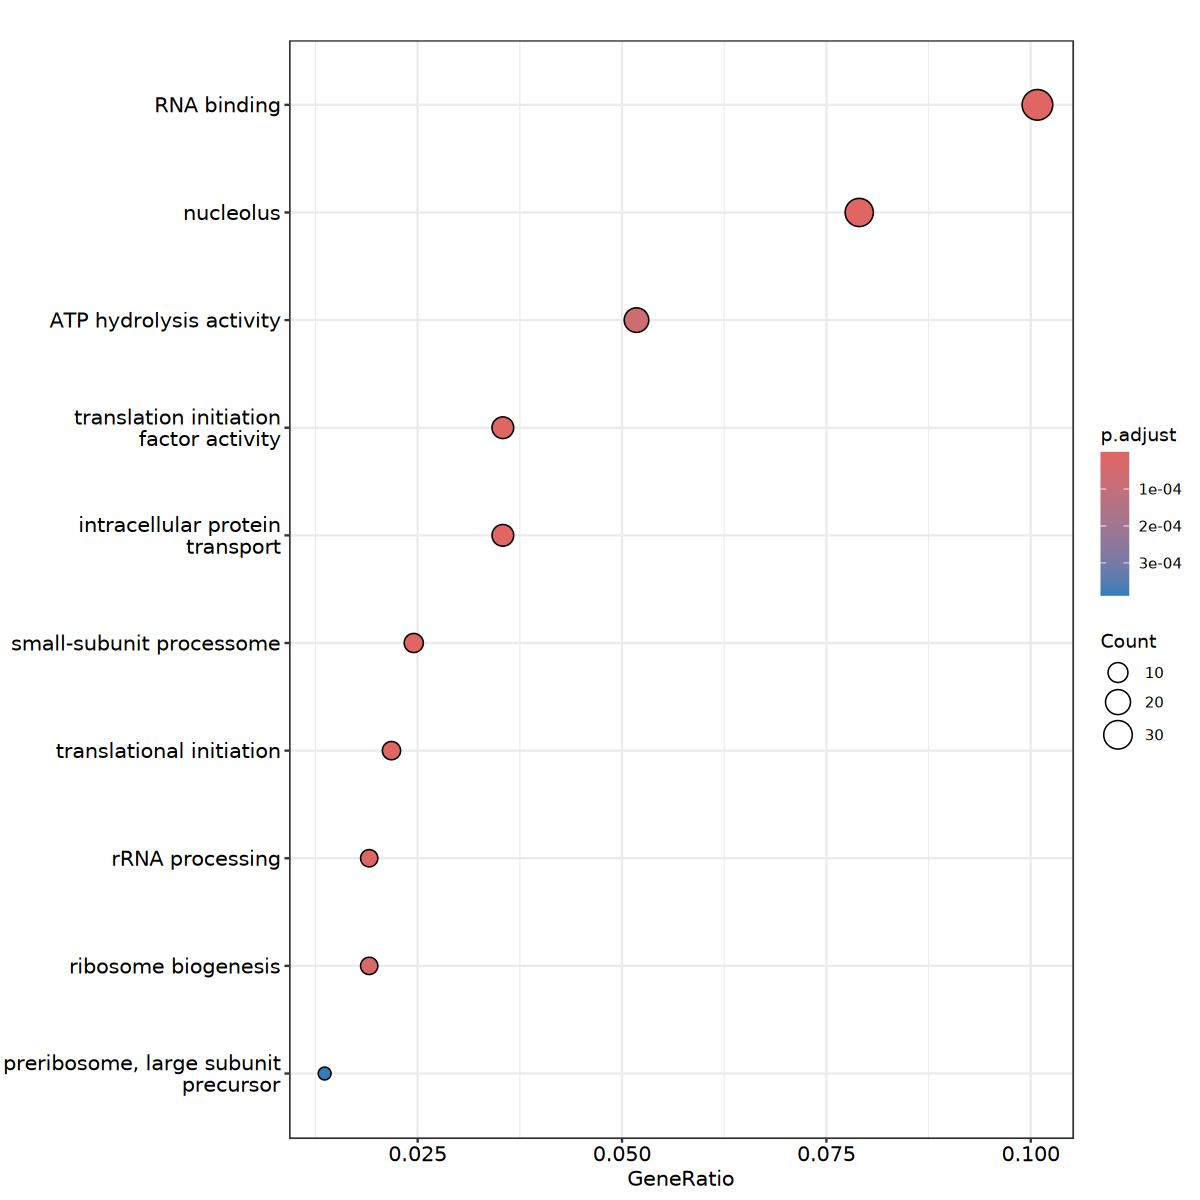

In [24]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "cyan") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
cyan_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

look for parent terms/bin GO terms to broader categories

In [25]:
cyan_mapped <- cyan_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
cyan_final <- cyan_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'cyan'")

head(cyan_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0005730,nucleolus,29/367,61/9286,4.707775e-25,9.980483e-23,8.771328e-23,LOC111099808/LOC111103978/LOC111104266/LOC111105066/LOC111105256/LOC111113203/LOC111118069/LOC111118739/LOC111118852/LOC111120775/LOC111120892/LOC111121130/LOC111123381/LOC111125438/LOC111127822/LOC111129891/LOC111130503/LOC111132132/LOC111132803/LOC111133059/LOC111133335/LOC111134594/LOC111135538/LOC111135552/LOC111135565/LOC111136220/LOC111136243/LOC111138243/LOC144626880,29,GO:0005730,nucleolus,'cyan'
GO:0003723,RNA binding,37/367,222/9286,5.402320e-14,3.817639e-12,3.355125e-12,LOC111099922/LOC111100592/LOC111105256/LOC111106149/LOC111107584/LOC111116966/LOC111117964/LOC111118049/LOC111118069/LOC111118140/LOC111118340/LOC111118362/LOC111118739/LOC111118852/LOC111119023/LOC111120863/LOC111123381/LOC111126771/LOC111127420/LOC111128711/LOC111129950/LOC111130503/LOC111130828/LOC111133159/LOC111133163/LOC111133985/LOC111134482/LOC111135060/LOC111135061/LOC111135353/LOC111135640/LOC111135736/LOC111135739/LOC111136243/LOC144622099/LOC144623848/LOC144625869,37,GO:0003723,RNA binding,'cyan'
GO:0006886,intracellular protein transport,13/367,51/9286,5.655757e-08,1.998367e-06,1.756261e-06,LOC111105624/LOC111114212/LOC111118971/LOC111121436/LOC111126975/LOC111130083/LOC111130192/LOC111130246/LOC111130418/LOC111133259/LOC111134551/LOC111135858/LOC111137990,13,GO:0006886,intracellular protein transport,'cyan'
GO:0006364,rRNA processing,7/367,13/9286,1.988262e-07,6.021595e-06,5.292067e-06,LOC111099808/LOC111118739/LOC111120892/LOC111125438/LOC111128896/LOC111129891/LOC111133335,7,GO:0042254,ribosome biogenesis,'cyan'
GO:0042254,ribosome biogenesis,7/367,16/9286,1.195463e-06,3.167978e-05,2.784171e-05,LOC111112843/LOC111118069/LOC111118140/LOC111120775/LOC111121217/LOC111133059/LOC111135912,7,GO:0042254,ribosome biogenesis,'cyan'
GO:0005739,mitochondrion,23/367,232/9286,4.369348e-05,7.125399e-04,6.262143e-04,LOC111099882/LOC111100042/LOC111100065/LOC111100599/LOC111103813/LOC111104353/LOC111105388/LOC111105692/LOC111107779/LOC111114527/LOC111115710/LOC111115725/LOC111118600/LOC111127891/LOC111128042/LOC111128143/LOC111128617/LOC111129316/LOC111130718/LOC111132172/LOC111134378/LOC111135733/LOC111138406,23,GO:0005739,mitochondrion,'cyan'


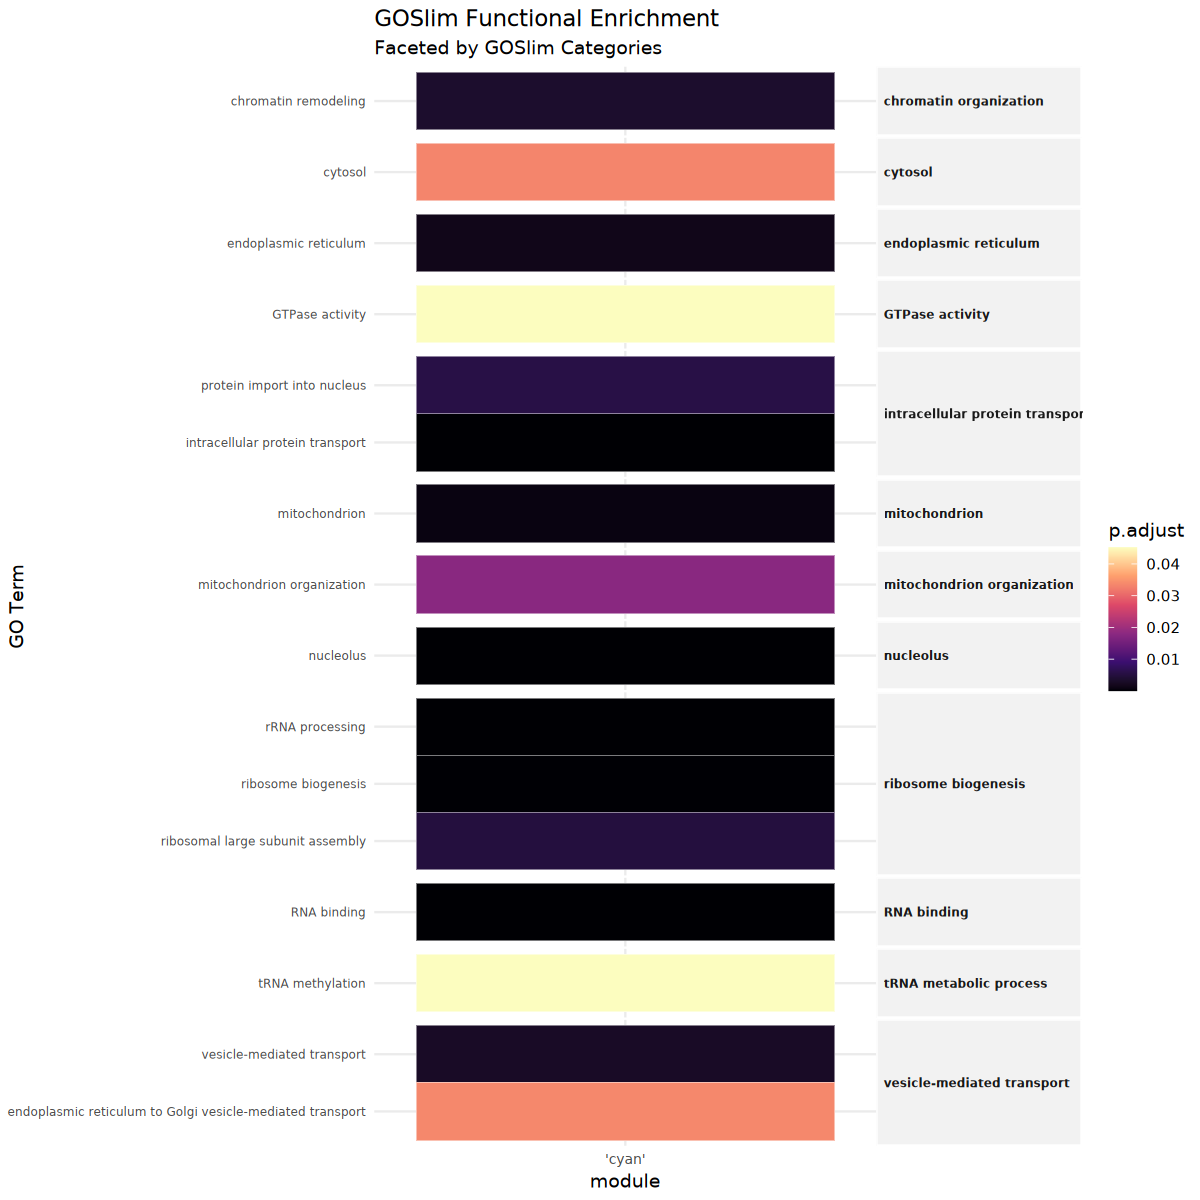

In [26]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(cyan_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

lots of energy and mitochondria related processes  - also transport and metabolism

### green module
neg. corr. with shell growth, pos. corr. with Both treatment (in relation to the other treatment options)

In [28]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "green") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
green_res <- as.data.frame(ego_custom)

green_res

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no enriched GO terms

### black module
neg. corr. with tissue:shell growth ratio

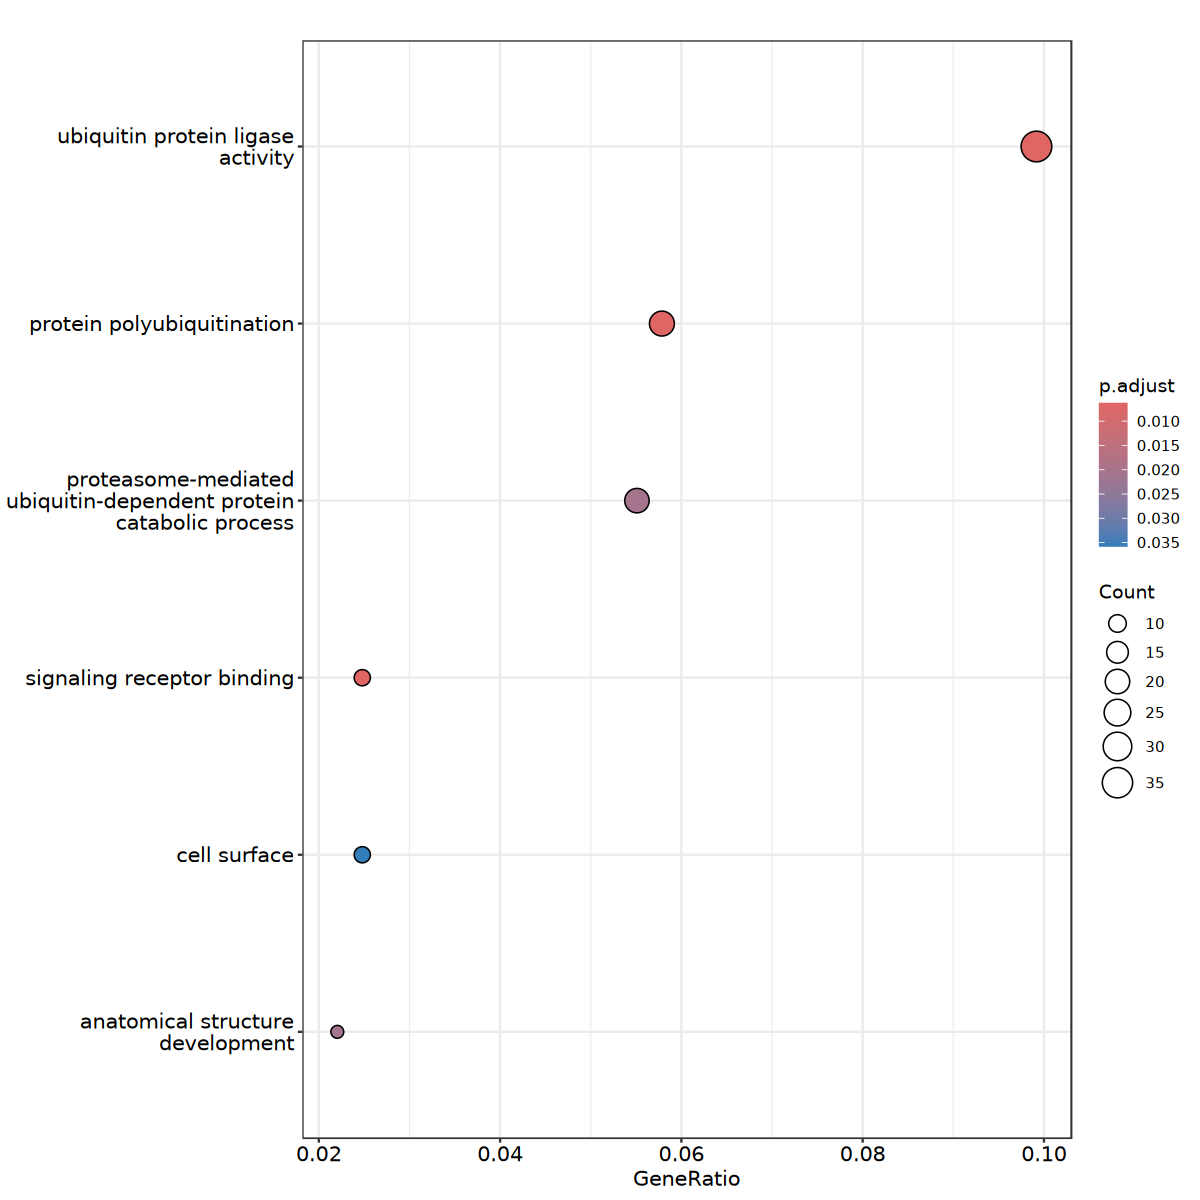

In [29]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "black") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
black_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

In [30]:
black_mapped <- black_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
black_final <- black_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'black'")

head(black_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0043161,proteasome-mediated ubiquitin-dependent protein catabolic process,20/363,220/9286,0.0003788439,0.02045757,0.01973976,LOC111104488/LOC111117739/LOC111117750/LOC111117751/LOC111120860/LOC111132770/LOC111132791/LOC111133281/LOC111133290/LOC111133291/LOC111136184/LOC144617450/LOC144617601/LOC144617768/LOC144617924/LOC144618012/LOC144618951/LOC144621743/LOC144623211/LOC144627284,20,GO:0030163,protein catabolic process,'black'
GO:0048856,anatomical structure development,8/363,48/9286,0.0004834528,0.02088516,0.02015235,LOC111135853/LOC144618347/LOC144618702/LOC144618710/LOC144618712/LOC144618719/LOC144618902/LOC144618906,8,GO:0048856,anatomical structure development,'black'


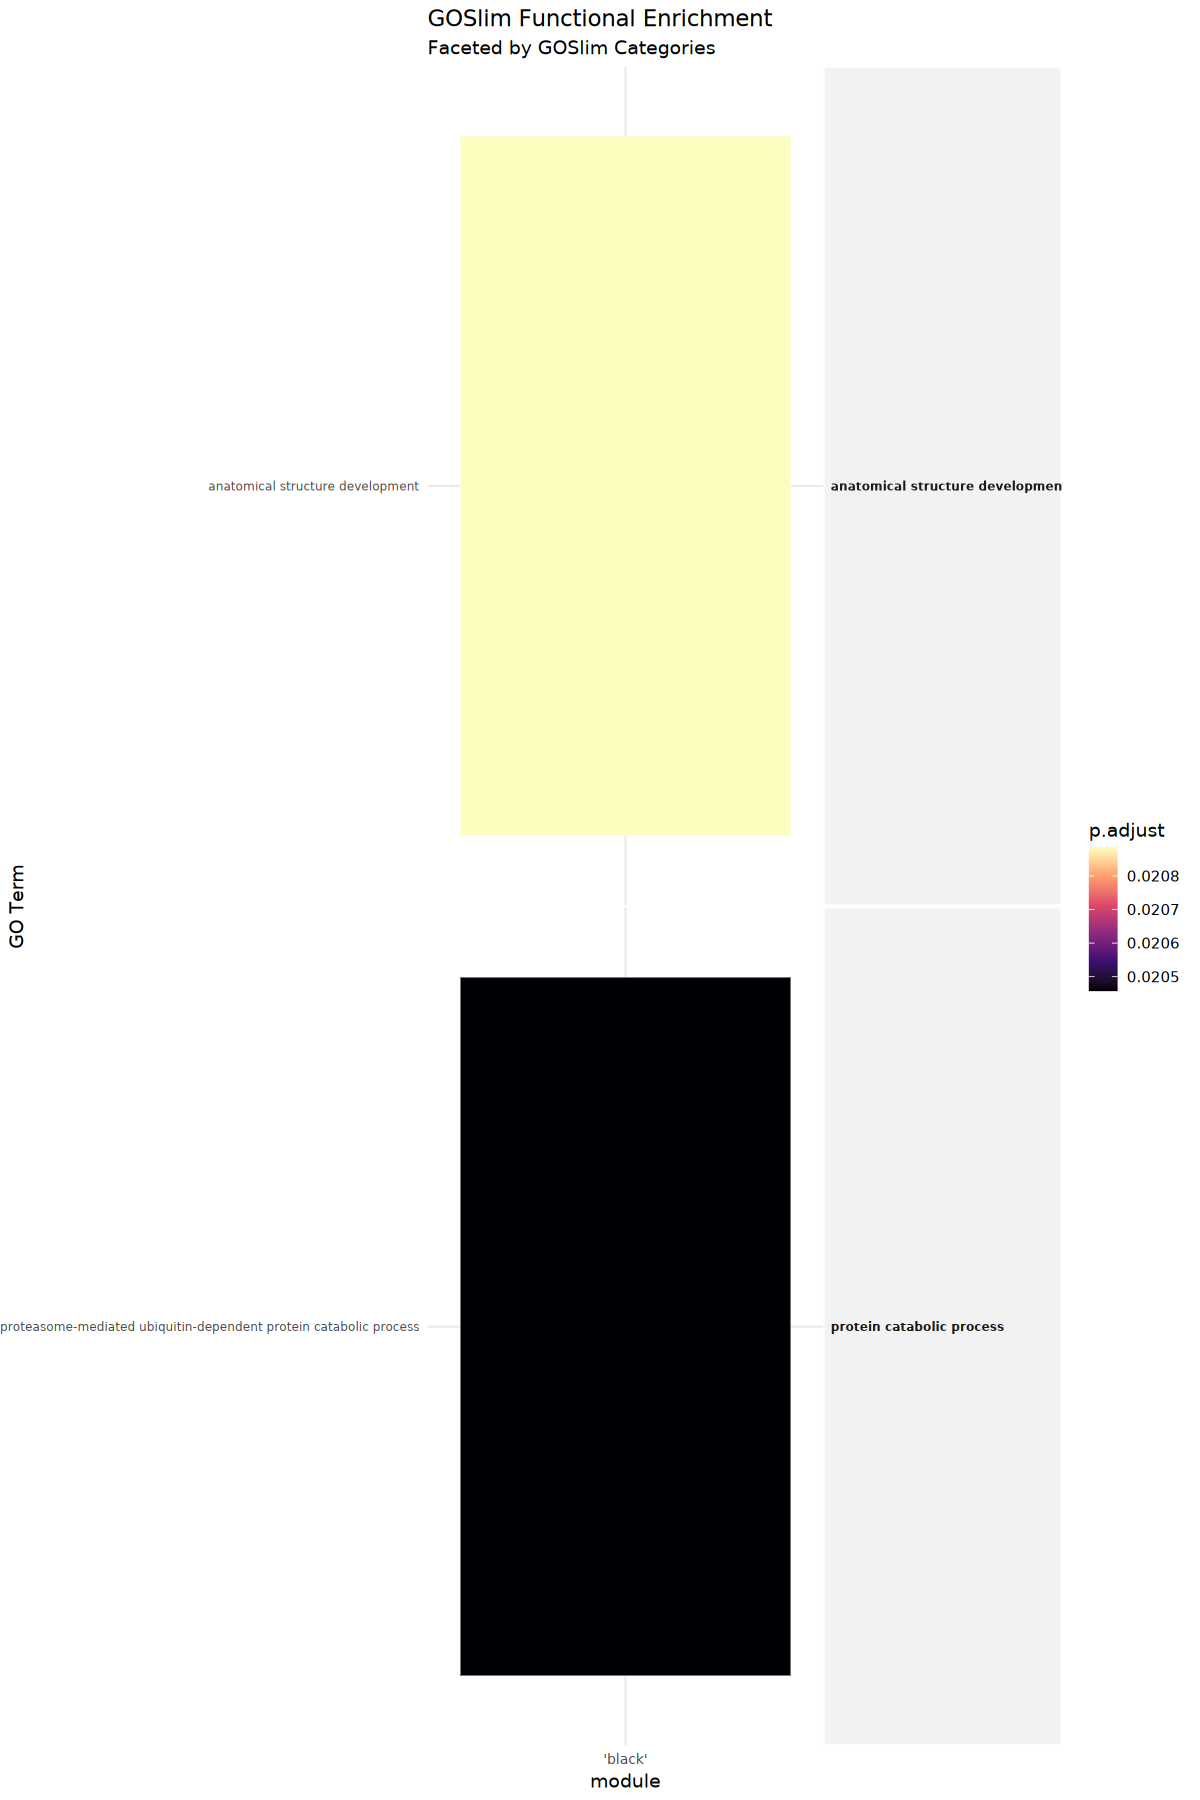

In [31]:
options(repr.plot.width = 10, repr.plot.height = 15)

ggplot(black_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

more structural development - cell differentation, adhesion, development - lots of signaling and transport

wound healing and programmed cell death is interesting too - these genes tend to have higher expression in treatments warm and hypoxic (single stressors) and lower in control conditions

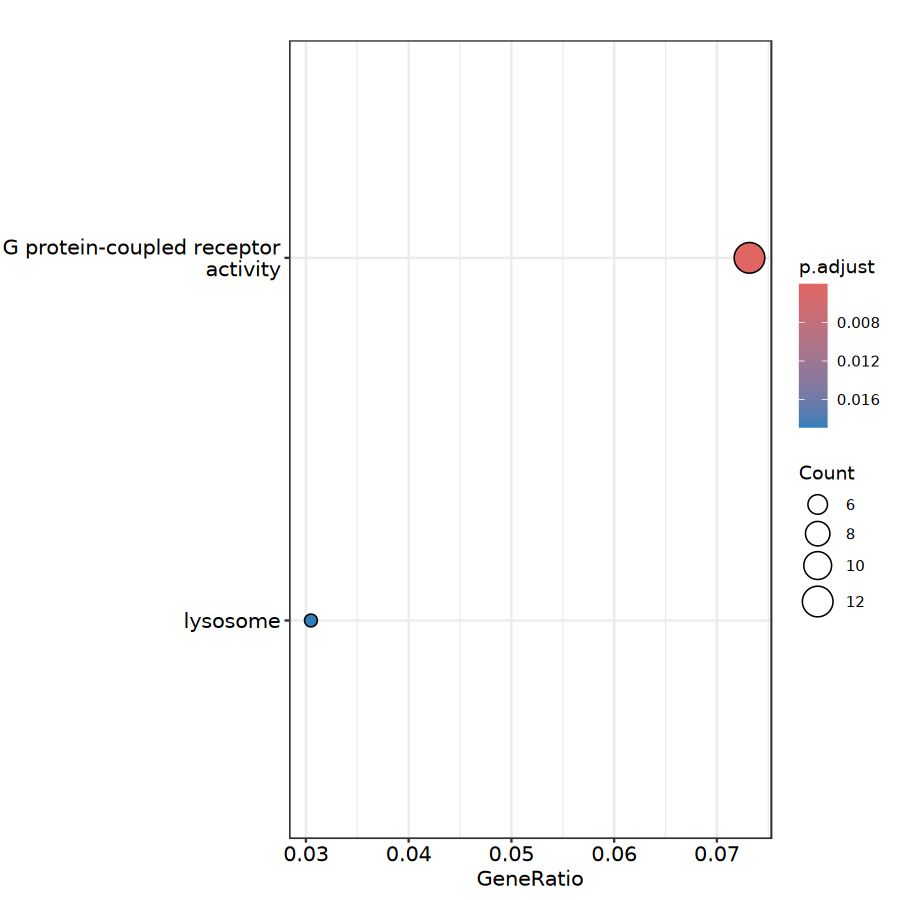

In [27]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

target_genes <- geneInfo %>%
  filter(ModuleColor == "salmon") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
salmon_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

- lysosome - the organism's waste disposal system
- G protein-coupled receptor activity - largest family of cell-surface receptors - primary sensory and messaging inbox

look for parent terms/bin GO terms to broader categories

In [28]:
salmon_mapped <- salmon_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
salmon_final <- salmon_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'salmon'")

head(salmon_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0005764,lysosome,5/164,33/9340,0.0002503416,0.01890079,0.01791919,LOC111106777/LOC111106925/LOC111121485/LOC111121750/LOC111127014,5,GO:0005764,lysosome,'salmon'


### royalblue module
pos. corr. with both treatment (relative to the other treatments)

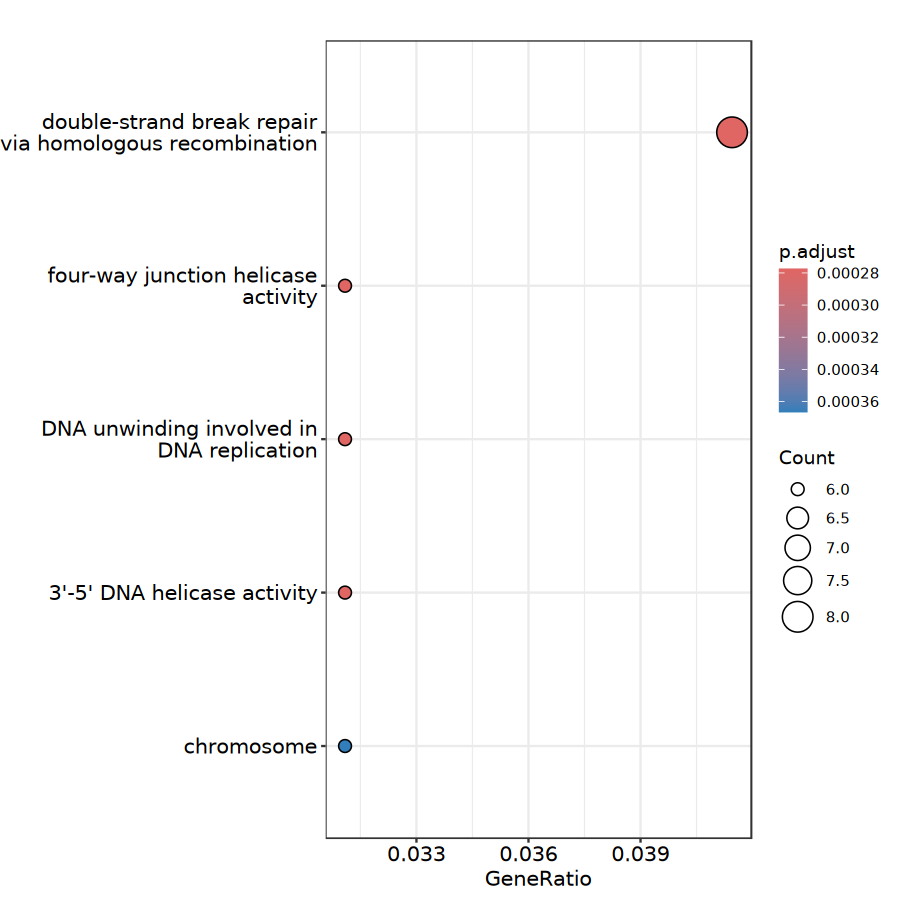

In [32]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

target_genes <- geneInfo %>%
  filter(ModuleColor == "royalblue") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
royalblue_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

oooo lots of helicase activity - so in relation to DNA repair

In [33]:
royalblue_mapped <- royalblue_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
royalblue_final <- royalblue_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'royalblue'")

head(royalblue_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0000724,double-strand break repair via homologous recombination,8/193,46/9286,3.994490e-06,0.0002773760,0.0002533026,LOC111103948/LOC111110332/LOC111115690/LOC111116012/LOC111118047/LOC111130258/LOC111130622/LOC144622668,8,GO:0006281,DNA repair,'royalblue'
GO:0006268,DNA unwinding involved in DNA replication,6/193,23/9286,5.607163e-06,0.0002773760,0.0002533026,LOC111103948/LOC111115690/LOC111116012/LOC111118047/LOC111130258/LOC144622668,6,GO:0006260,DNA replication,'royalblue'
GO:0005694,chromosome,6/193,26/9286,1.214027e-05,0.0003666362,0.0003348159,LOC111103948/LOC111115690/LOC111116012/LOC111118047/LOC111130258/LOC144622668,6,GO:0005694,chromosome,'royalblue'


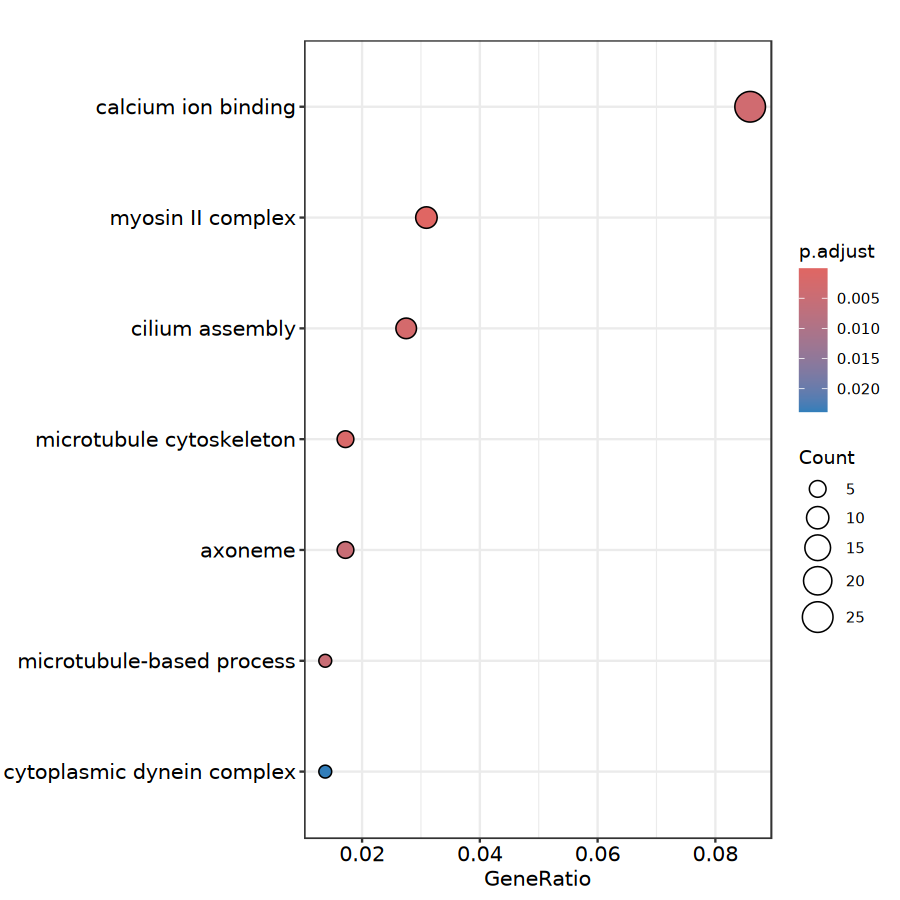

In [31]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

# purple 
target_genes <- geneInfo %>%
  filter(ModuleColor == "purple") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
purple_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

In [32]:
purple_mapped <- purple_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
purple_final <- purple_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'purple'")

head(purple_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0060271,cilium assembly,8/291,43/9340,4.523511e-05,0.002623637,0.002380795,LOC111106953/LOC111107237/LOC111118797/LOC111120729/LOC111121573/LOC111130289/LOC111135089/LOC111136209,8,GO:0044782,cilium organization,'purple'


## combining these:

In [34]:
# combine all sig. modules GO results
module.GO <- rbind(greenyellow_final, cyan_final, black_final, royalblue_final)

In [36]:
# add whether the module was sig. correlated with phase 1 or phase 2 treatments/traits
 module.GO <- module.GO %>%
 mutate(sigCor_phase = 'phase1')

# check it worked
head(module.GO)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module,sigCor_phase
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
GO:0005739,mitochondrion,61/989,232/9286,9.231462e-12,3.147929e-09,2.711135e-09,LOC111100670/LOC111104137/LOC111104154/LOC111104191/LOC111104253/LOC111104483/LOC111104702/LOC111105866/LOC111106365/LOC111107126/LOC111107699/LOC111113204/LOC111114229/LOC111116418/LOC111117758/LOC111117976/LOC111118028/LOC111118249/LOC111118461/LOC111118962/LOC111120825/LOC111120828/LOC111120899/LOC111121538/LOC111121564/LOC111121759/LOC111125126/LOC111125202/LOC111127785/LOC111127815/LOC111127947/LOC111128123/LOC111128302/LOC111128521/LOC111128646/LOC111129097/LOC111129859/LOC111129960/LOC111130026/LOC111130095/LOC111130179/LOC111130538/LOC111130608/LOC111130738/LOC111130742/LOC111132779/LOC111133074/LOC111133078/LOC111133426/LOC111133477/LOC111133507/LOC111134458/LOC111134852/LOC111135308/LOC111135530/LOC111135916/LOC111136154/LOC144620891/LOC144622705/LOC144622927/LOC144627595,61,GO:0005739,mitochondrion,'greenyellow',phase1
GO:0000398,"mRNA splicing, via spliceosome",16/989,36/9286,2.257513e-07,3.849060e-05,3.314980e-05,LOC111104149/LOC111106006/LOC111106010/LOC111106208/LOC111111061/LOC111118582/LOC111119055/LOC111121238/LOC111129054/LOC111135499/LOC111136320/LOC111136408/LOC111138363/LOC111138391/LOC144618296/LOC144622290,16,GO:0016071,mRNA metabolic process,'greenyellow',phase1
GO:0006457,protein folding,15/989,33/9286,3.775461e-07,4.291440e-05,3.695977e-05,LOC111106300/LOC111107136/LOC111114582/LOC111120649/LOC111120828/LOC111121532/LOC111125459/LOC111128545/LOC111128611/LOC111128632/LOC111128939/LOC111129850/LOC111130072/LOC111133727/LOC111134667,15,GO:0006457,protein folding,'greenyellow',phase1
GO:0060271,cilium assembly,16/989,43/9286,3.978499e-06,3.391671e-04,2.921056e-04,LOC111105908/LOC111106953/LOC111107237/LOC111118542/LOC111118797/LOC111120826/LOC111121573/LOC111129512/LOC111130072/LOC111130439/LOC111134366/LOC111134972/LOC111135089/LOC111135793/LOC111136209/LOC111138025,16,GO:0044782,cilium organization,'greenyellow',phase1
GO:0005829,cytosol,54/989,281/9286,1.032583e-05,6.664223e-04,5.739522e-04,LOC111103044/LOC111103864/LOC111103886/LOC111104191/LOC111105293/LOC111105636/LOC111106068/LOC111107093/LOC111110954/LOC111111015/LOC111112221/LOC111113059/LOC111113199/LOC111116740/LOC111118136/LOC111118247/LOC111118582/LOC111118918/LOC111118963/LOC111120899/LOC111121293/LOC111125457/LOC111127104/LOC111127241/LOC111127358/LOC111127391/LOC111127492/LOC111127774/LOC111128121/LOC111128253/LOC111128304/LOC111128611/LOC111129847/LOC111129850/LOC111129886/LOC111130366/LOC111130491/LOC111130537/LOC111132796/LOC111133013/LOC111133780/LOC111133890/LOC111135006/LOC111135530/LOC111136223/LOC111138068/LOC111138323/LOC144625404/LOC144625422/LOC144625455/LOC144626444/LOC144626796/LOC144626843/LOC144626856,54,GO:0005829,cytosol,'greenyellow',phase1
GO:0006890,"retrograde vesicle-mediated transport, Golgi to endoplasmic reticulum",7/989,12/9286,7.442482e-05,2.307169e-03,1.987036e-03,LOC111105880/LOC111114496/LOC111125460/LOC111127011/LOC111132171/LOC111134608/LOC111134680,7,GO:0016192,vesicle-mediated transport,'greenyellow',phase1


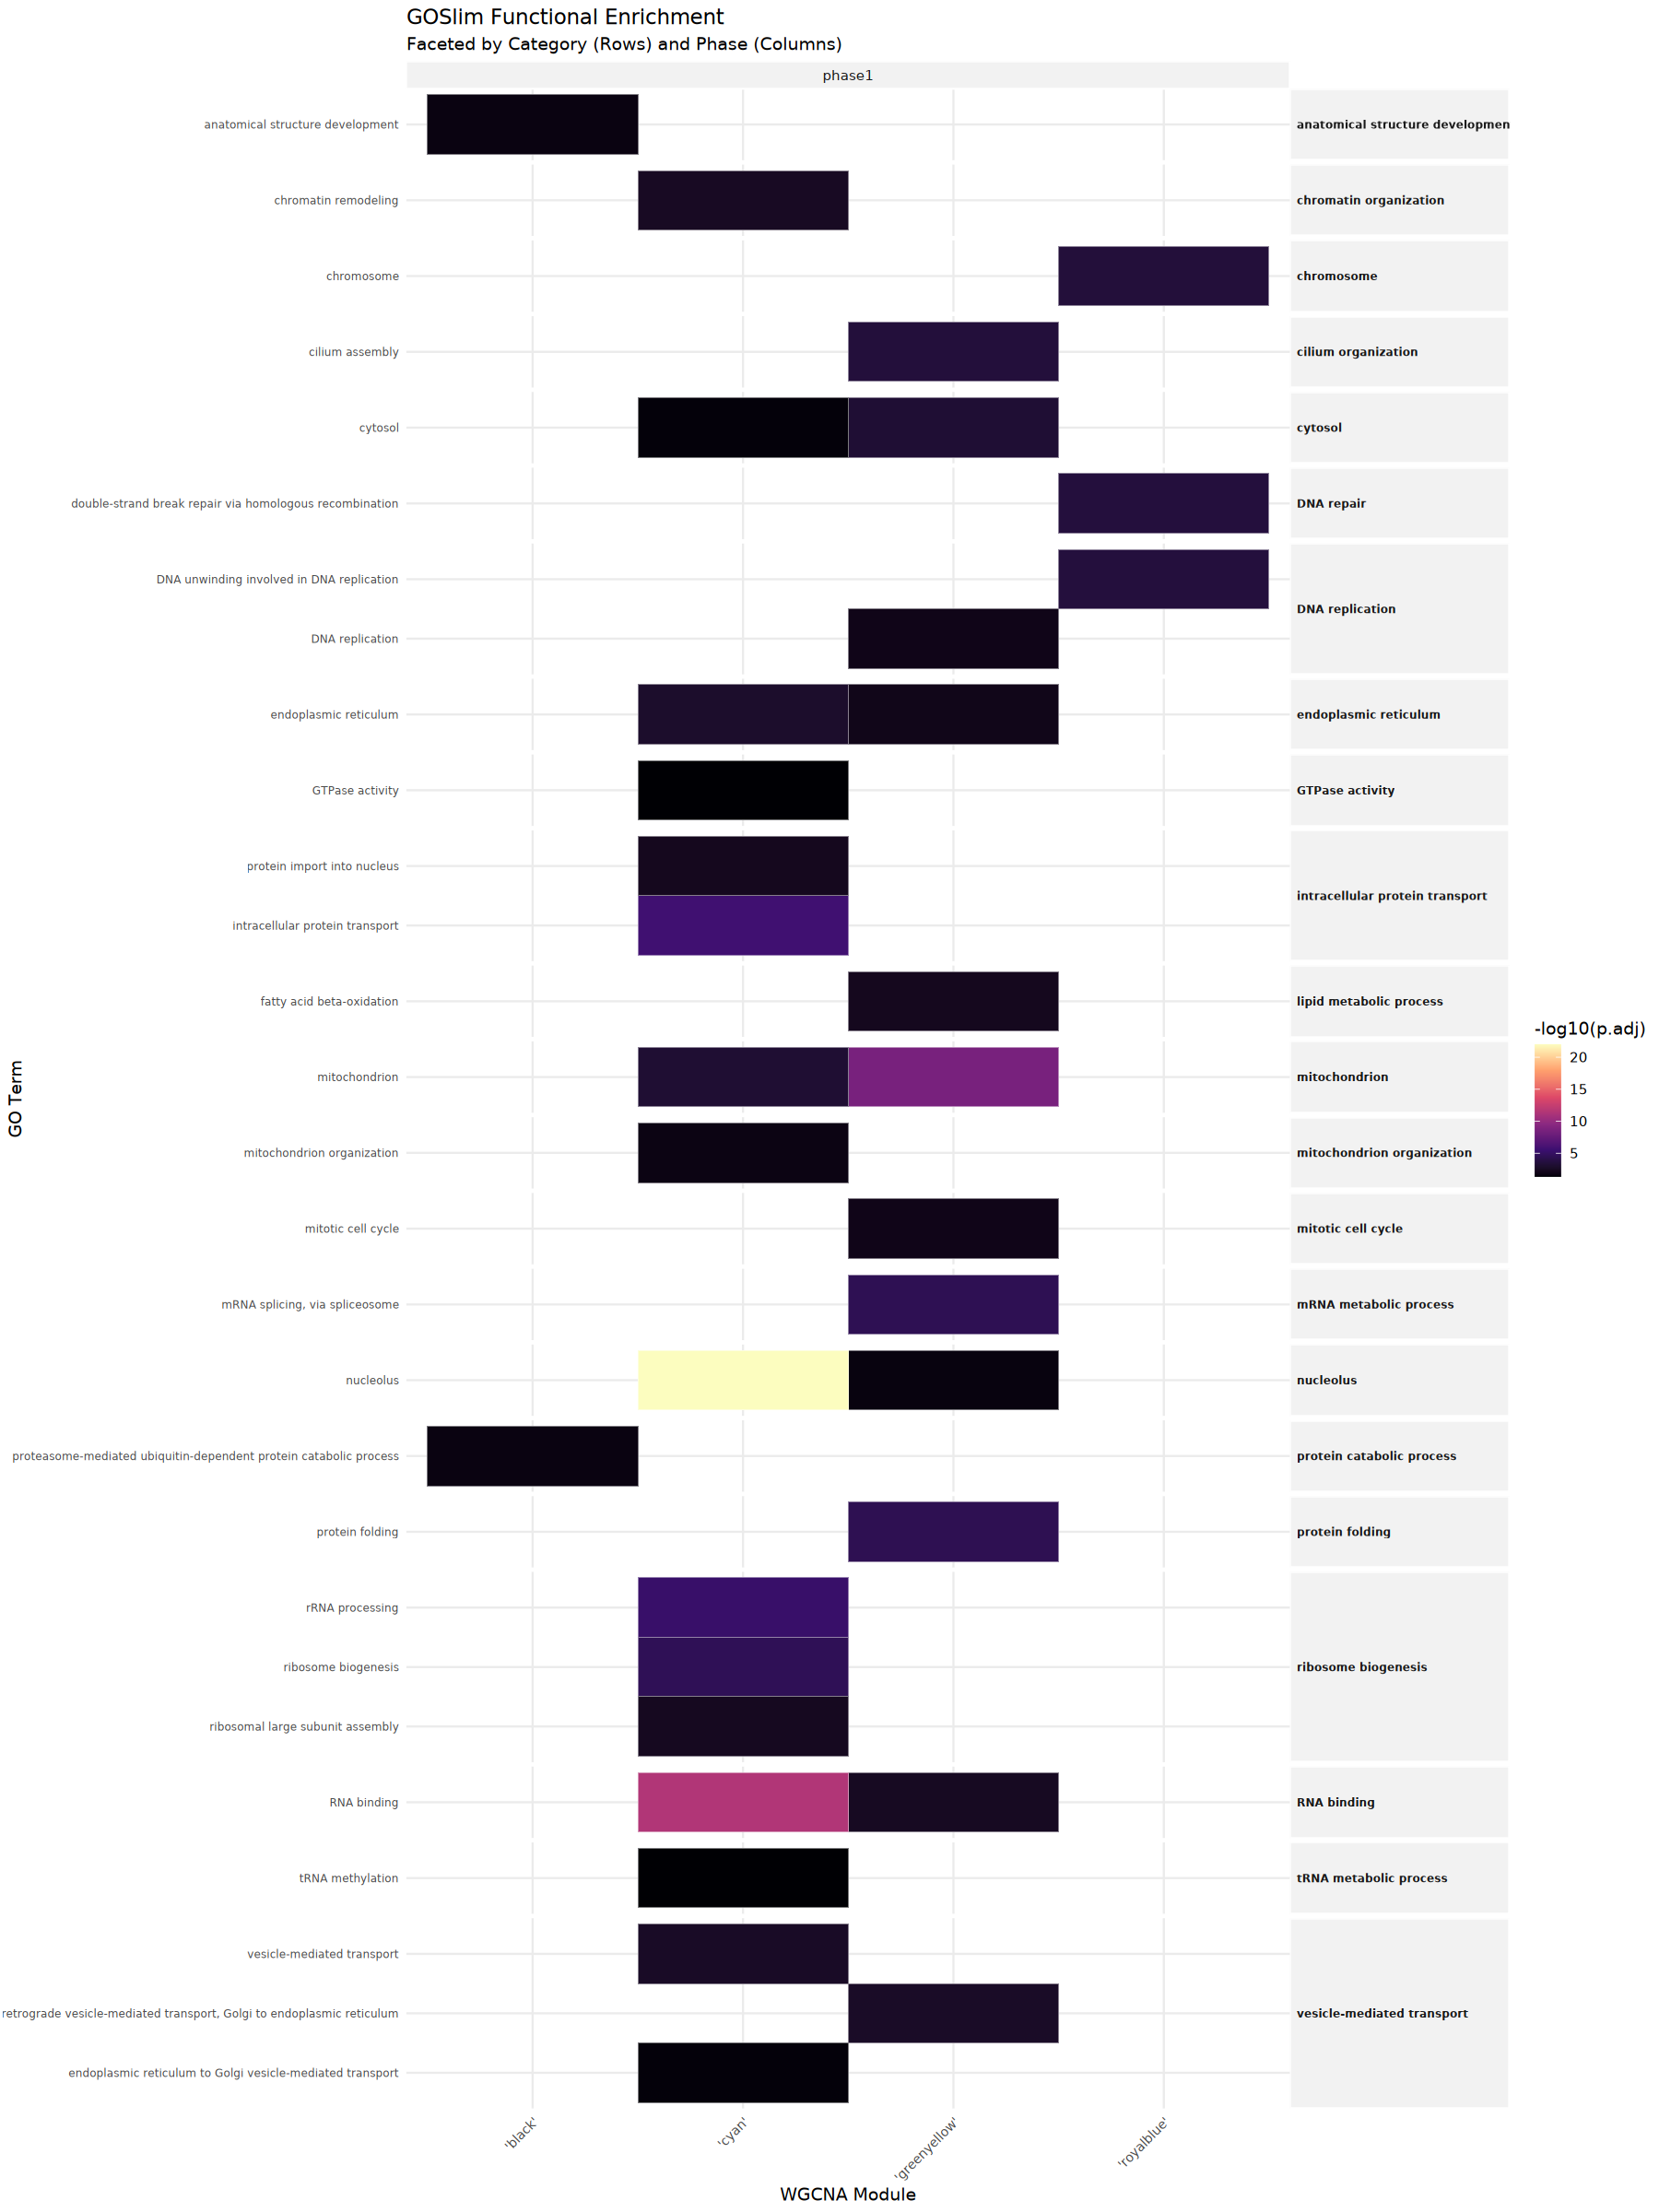

In [37]:
options(repr.plot.width = 15, repr.plot.height = 20)

ggplot(module.GO, aes(x = module, y = Description, fill = -log10(p.adjust))) +
  geom_tile(color = "white", linewidth = 0.1) + 
  # Rows = GOSlim_Bin, Columns = sigCor_phase
facet_grid(GOSlim_Bin ~ sigCor_phase, scales = "free", space = "free") +
scale_fill_viridis_c(option = "magma", name = "-log10(p.adj)") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
    panel.spacing = unit(0.2, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by Category (Rows) and Phase (Columns)",
    y = "GO Term",
    x = "WGCNA Module"
  )

what if we remove GO terms - look at just GOSlim categories

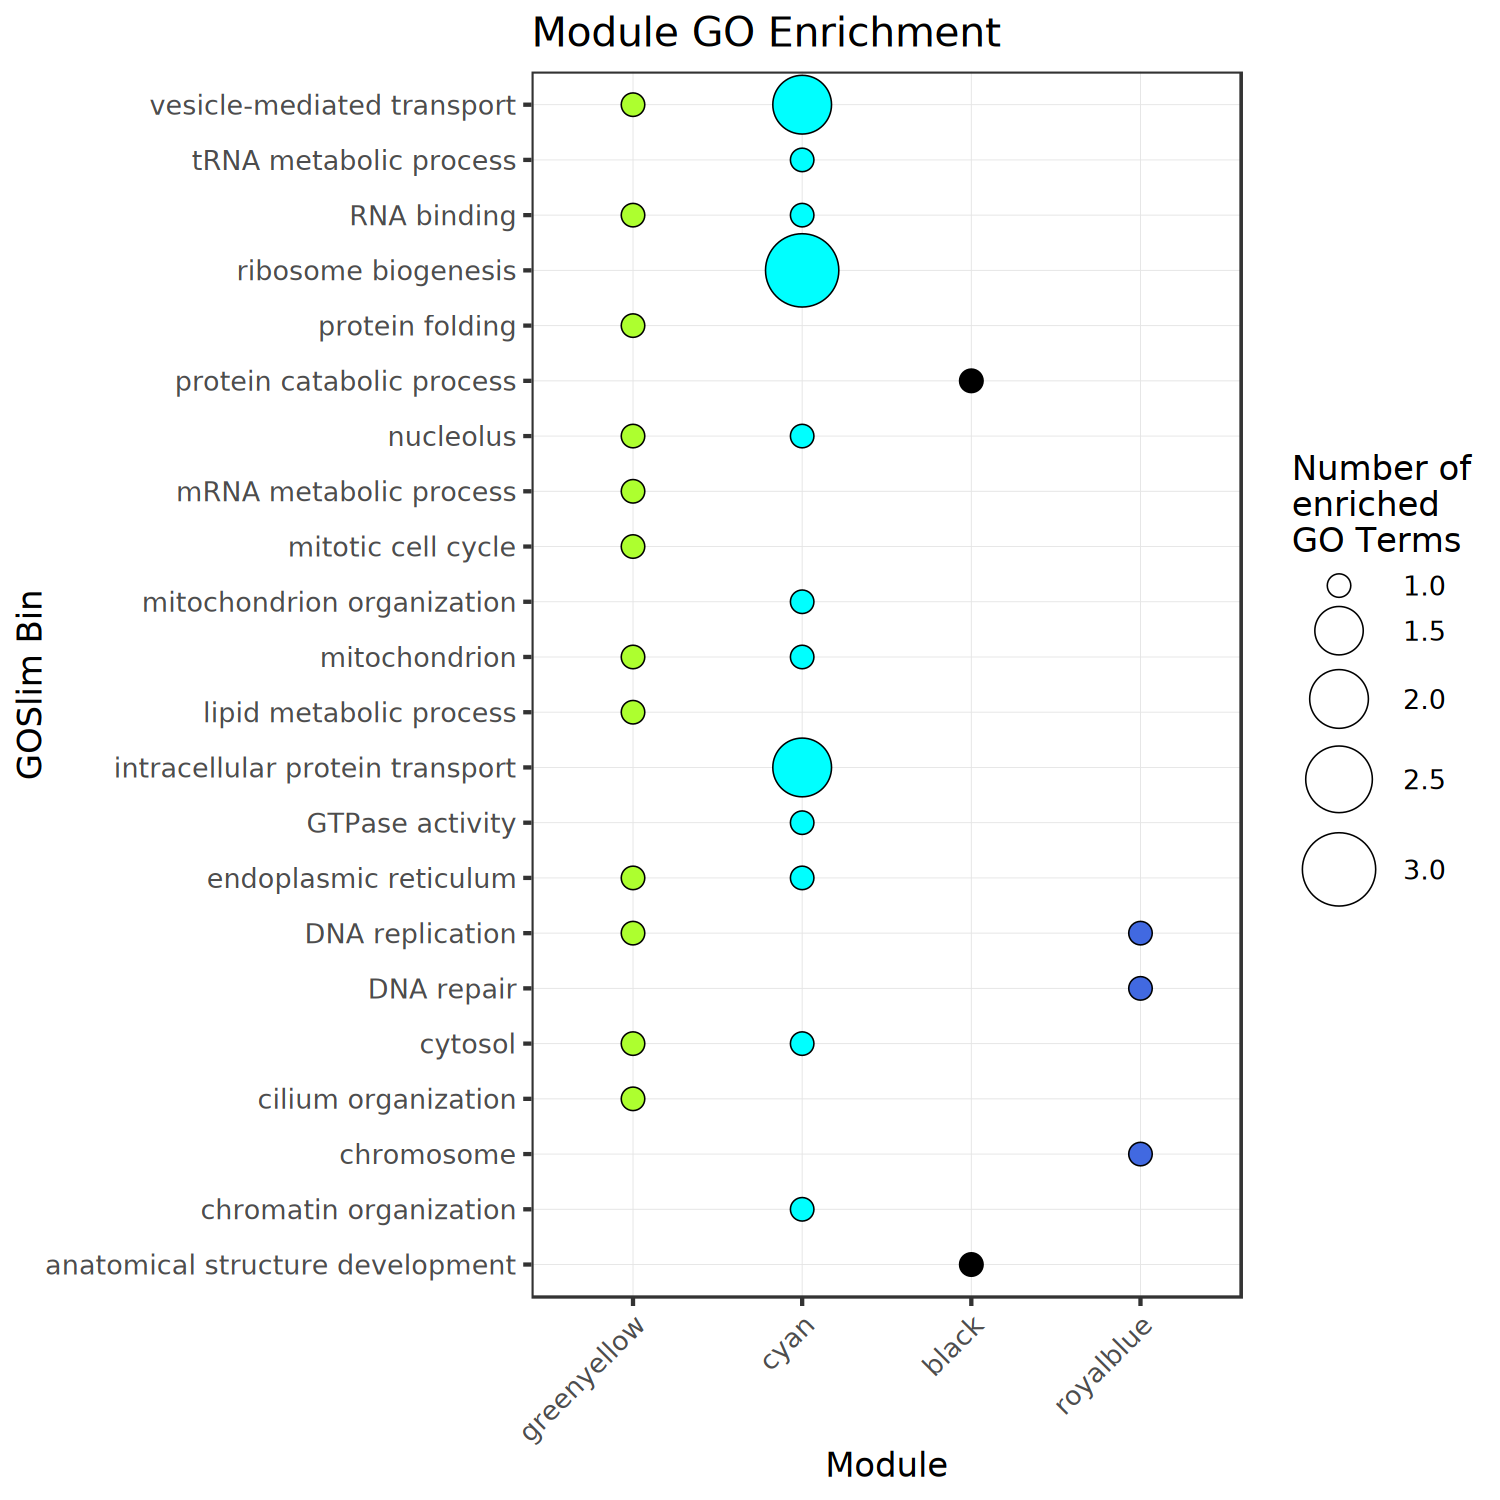

In [39]:
options(repr.plot.width = 12.5, repr.plot.height = 12.5)

# clean the strings and summarize
plot_summary <- module.GO %>%
  filter(!is.na(GOSlim_Bin), GOSlim_Bin != "", !is.na(sigCor_phase)) %>%
  # CLEANING STEP: Remove single quotes if they exist (e.g., 'green' -> green)
  mutate(module = str_replace_all(module, "'", "")) %>%
  group_by(module, GOSlim_Bin, sigCor_phase) %>%
  dplyr::summarize(GO_Count = n(), .groups = 'drop') %>% 
  mutate(across(where(is.character), as.factor))

plot_summary <- droplevels(plot_summary)

# manually set order of x-axis
plot_summary <- plot_summary %>%
  mutate(module = factor(module, levels = c(
    "greenyellow", "cyan", "black", "royalblue"  
  )))

# plot
ggplot(plot_summary, aes(x = module, y = GOSlim_Bin)) +
  # shape 21 uses 'fill' for the center and 'color' for the border
  geom_point(aes(size = GO_Count, fill = module), shape = 21, color = "black", stroke = 0.5) + 
  #facet_grid(. ~ sigCor_phase, scales = "free_x", space = "free_x") +
  # Tell ggplot to use the literal module names for the fill
  scale_fill_identity() + 
  scale_size_continuous(range = c(6, 20), name = "Number of\nenriched\nGO Terms") +
  theme_bw(base_size = 20) +
  theme(
    #axis.text.y = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.spacing = unit(1, "lines"),
    panel.grid.major = element_line(color = "gray90", size = 0.2)
  ) +
  labs(
    title = "Module GO Enrichment",
    #subtitle = "Size = Term Count | Color = WGCNA Module",
    y = "GOSlim Bin",
    x = "Module"
  )

here, the phase 1 column is for modules associated with phase 1 treatments (treatment as a whole or isolated temp/DO), and same for phase 2 - these results are from oysters that experienced both phase 1 *and* 2

### Module-Trait GO Enrichment

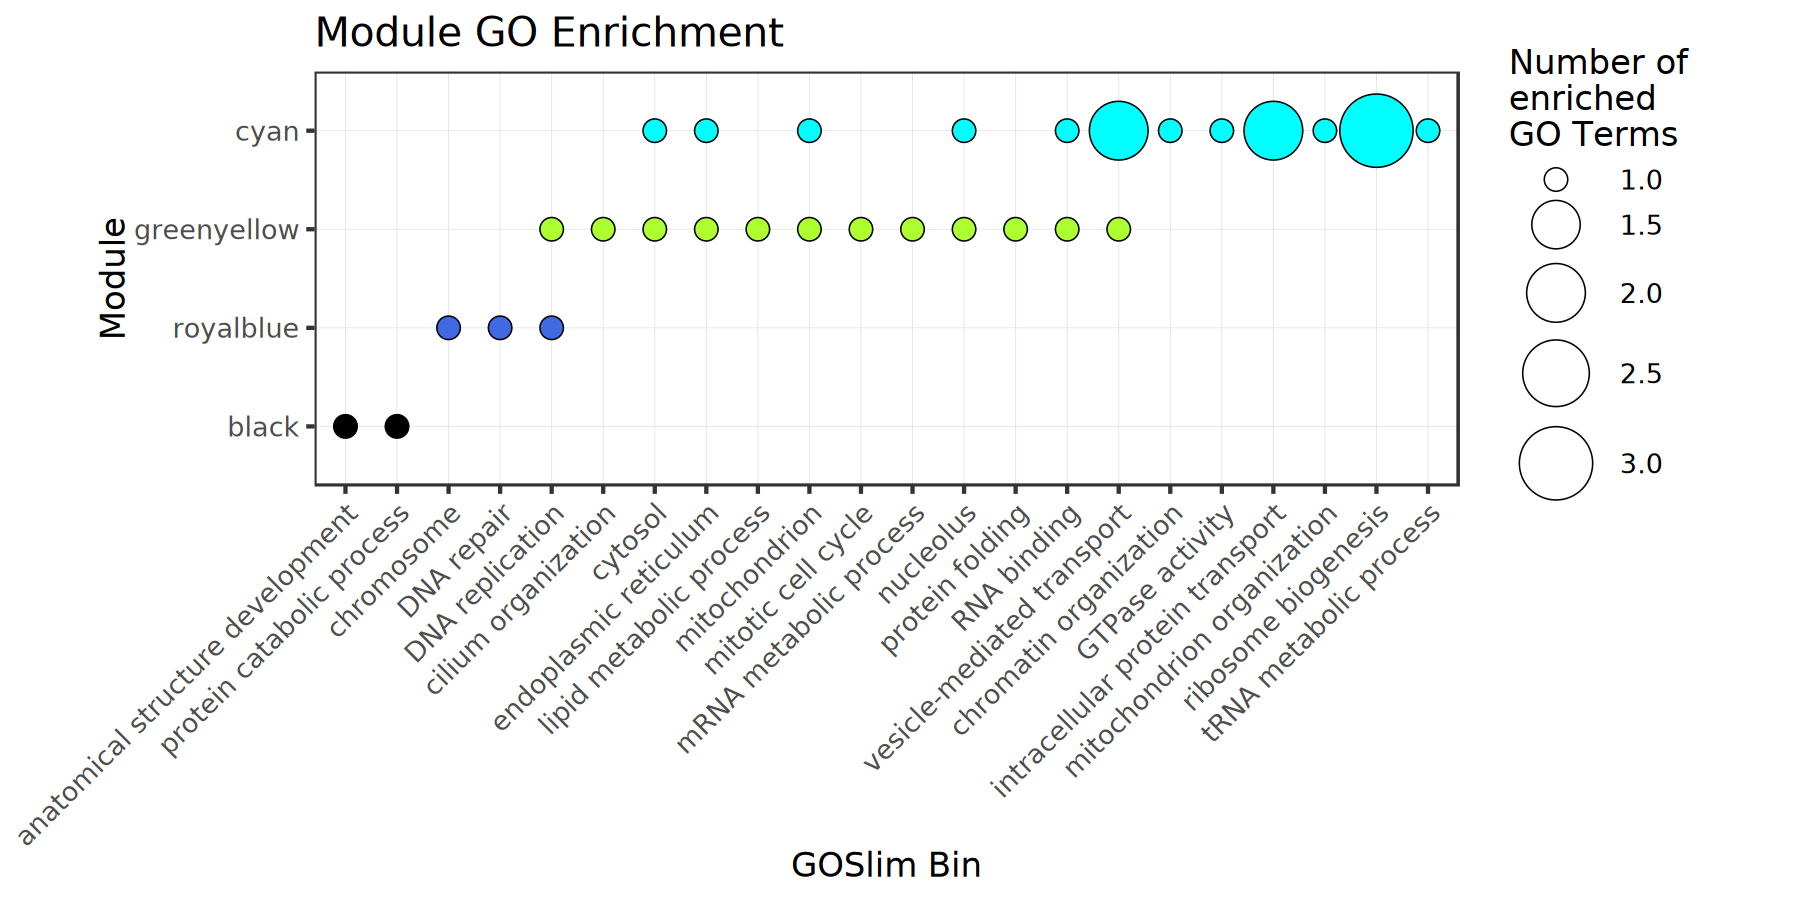

In [43]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

# clean the strings and summarize
plot_summary <- module.GO %>%
  filter(!is.na(GOSlim_Bin), GOSlim_Bin != "", !is.na(sigCor_phase)) %>%
  # CLEANING STEP: Remove single quotes if they exist (e.g., 'green' -> green)
  mutate(module = str_replace_all(module, "'", "")) %>%
  group_by(module, GOSlim_Bin, sigCor_phase) %>%
  dplyr::summarize(GO_Count = n(), .groups = 'drop') %>% 
  mutate(across(where(is.character), as.factor))

plot_summary <- droplevels(plot_summary)

module_priority <- c("black", "royalblue", "greenyellow", "cyan")

go_order <- plot_summary %>%
  mutate(module = factor(module, levels = module_priority)) %>%
  arrange(module, GOSlim_Bin) %>%
  pull(GOSlim_Bin) %>%
  unique()

plot_summary <- plot_summary %>%
  mutate(
    module = factor(module, levels = module_priority),
    GOSlim_Bin = factor(GOSlim_Bin, levels = go_order)
  )

# plot
ggplot(plot_summary, aes(x = module, y = GOSlim_Bin)) +
coord_flip() +
  # shape 21 uses 'fill' for the center and 'color' for the border
  geom_point(aes(size = GO_Count, fill = module), shape = 21, color = "black", stroke = 0.5) + 
  #facet_grid(. ~ sigCor_phase, scales = "free_x", space = "free_x") +
  # Tell ggplot to use the literal module names for the fill
  scale_fill_identity() + 
  scale_size_continuous(range = c(6, 20), name = "Number of\nenriched\nGO Terms") +
  theme_bw(base_size = 20) +
  theme(
    #axis.text.y = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.spacing = unit(1, "lines"),
    panel.grid.major = element_line(color = "gray90", size = 0.2),
   plot.margin = margin(10, 60, 10, 60)
  ) +
  labs(
    title = "Module GO Enrichment",
    #subtitle = "Size = Term Count | Color = WGCNA Module",
    y = "GOSlim Bin",
    x = "Module"
  )

**observations/notes:**

seems like there's a lot of overlap of the **greenyellow** and **cyan** modules - they both are positively correlated with increased shell growth - so when there's increase in shell growth, there's also higher expression in mitochondrial and metabolic/energy processes
- in the context of the gill, maybe the gill needs to take in more food/process more energy to help facilitate shell growth? 

the **black** module is negatively correlated with tissue:shell growth (so when there is an increase in tissue growth relative to shell (i.e., investment in reproduction?), we see a decrease in processes related to development and catabolism 
- in the context of the gill, maybe tissue is less resource-intensive than shell? maybe the gill has more involvement in making the shell? maybe the gill doesn't change in size, but other tissues do?

the **royalblue** module is positively correlated with the both treatment (so when an oyster experiences simultaneous/multi stressors, this group of genes has higher expression compared to those that experience single stressors or no stress) - we see DNA repair and replication implicated
- I think this makes sense, as experiencing two stressors at the same time would be more stressful than the other treatments, and so an upregulation in DNA repair and replication implies there is cellular damage to the oyster

**add number of genes to the module names**

In [61]:
moduleCount <- count(geneInfo$ModuleColor)

colnames(moduleCount) <- c('module', 'freq')
head(moduleCount)

,module,freq
,<chr>,<int>
1,black,363
2,blue,611
3,brown,476
4,cyan,367
5,darkgreen,162
6,darkgrey,184


# I STOPPED HERE

In [62]:
module_priority <- c("black", "royalblue", "greenyellow", "cyan")

# create ordered labels for x-axis
color_order <- moduleCount %>%
  mutate(module = factor(module, levels = module_priority)) %>%
  arrange(module) %>%
  pull(color_count)

go_order <- plot_summary2 %>%
  mutate(module = factor(module, levels = module_priority)) %>%
  arrange(module, GOSlim_Bin) %>%
  pull(GOSlim_Bin) %>%
  unique()

plot_summary2 <- plot_summary2 %>%
  mutate(
    module = factor(module, levels = module_priority),
    color_count = factor(color_count, levels = color_order),
    GOSlim_Bin = factor(GOSlim_Bin, levels = go_order)
  )

head(plot_summary2)

ERROR: [1m[33mError[39m in `pull()`:[22m
[1mCaused by error:[22m
[33m![39m object 'color_count' not found


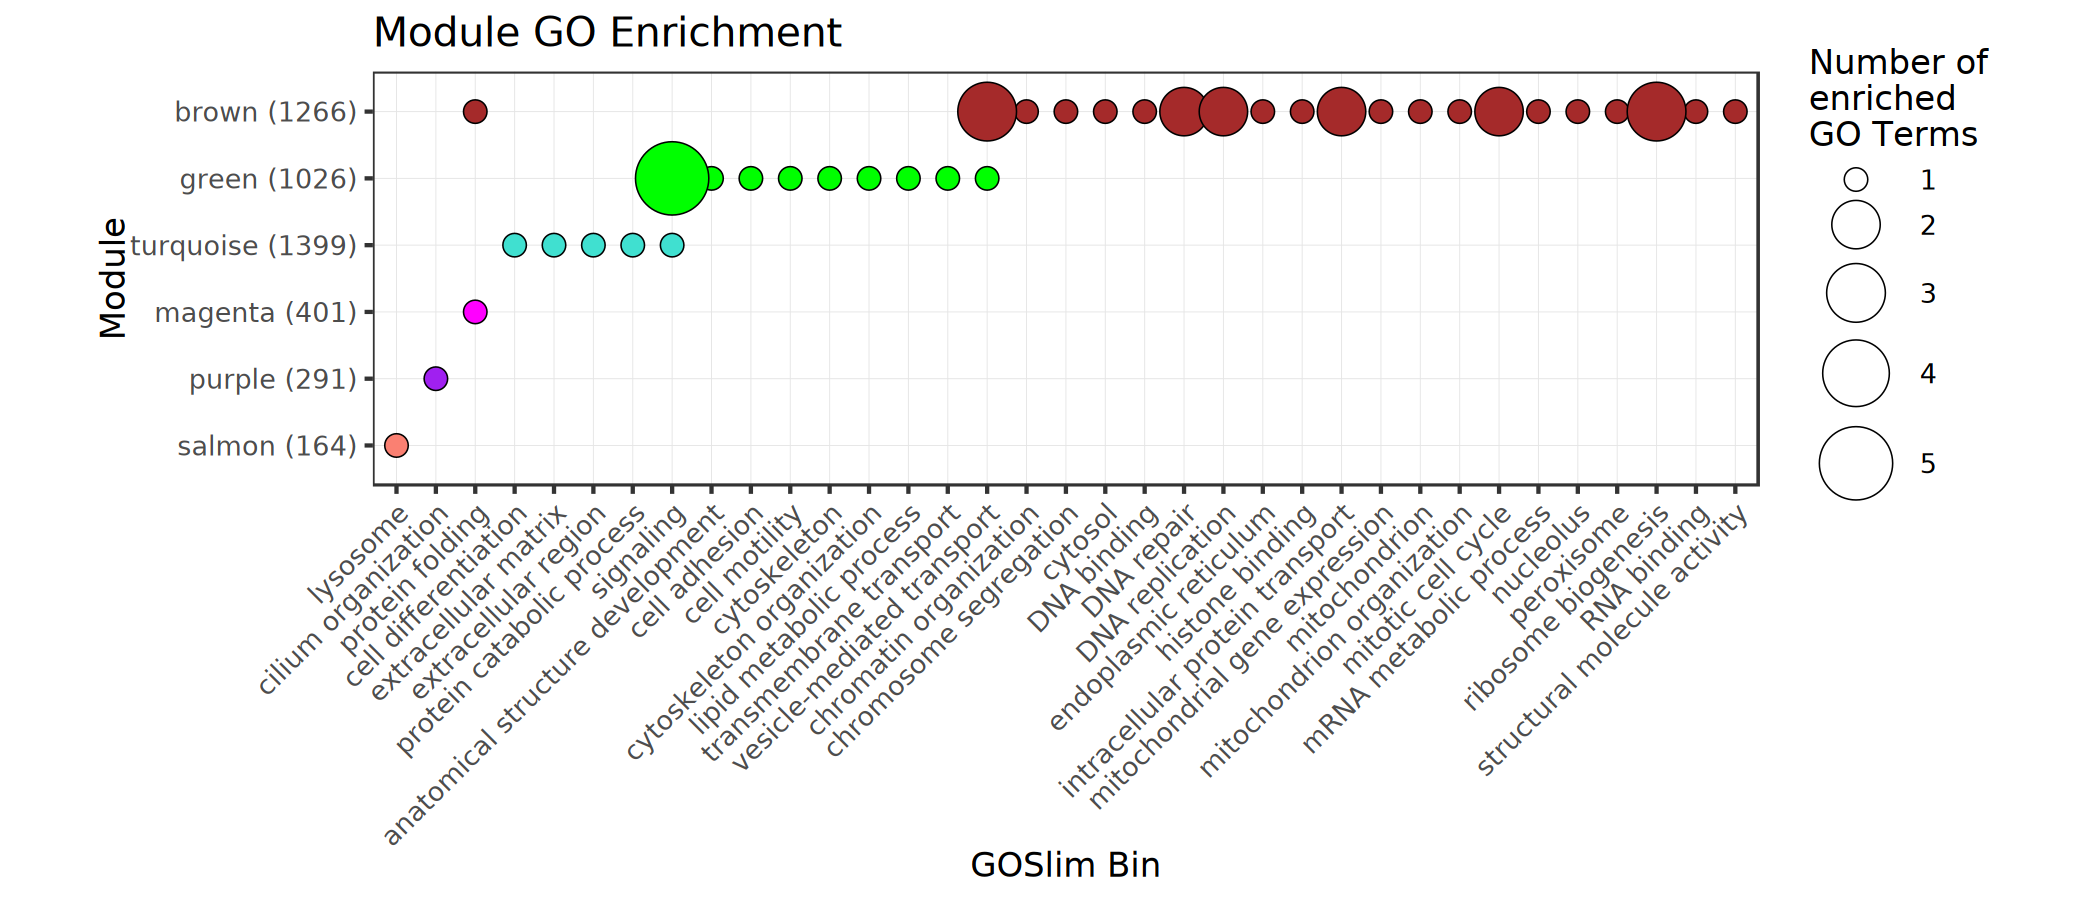

In [59]:
options(repr.plot.height = 7.5, repr.plot.width = 17.5)

# plot
go.plot <- ggplot(plot_summary2, aes(x = color_count, y = GOSlim_Bin)) +
coord_flip() +
  # shape 21 uses 'fill' for the center and 'color' for the border
  geom_point(aes(size = GO_Count, fill = module), shape = 21, color = "black", stroke = 0.5) + 
  # Tell ggplot to use the literal module names for the fill
  scale_fill_identity() + 
  scale_size_continuous(range = c(6, 20), name = "Number of\nenriched\nGO Terms") +
  theme_bw(base_size = 20) +
  theme(
    #axis.text.y = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.spacing = unit(1, "lines"),
    panel.grid.major = element_line(color = "gray90", size = 0.2),
   plot.margin = margin(10, 60, 10, 60)
  ) +
  labs(
    title = "Module GO Enrichment",
    #subtitle = "Size = Term Count | Color = WGCNA Module",
    y = "GOSlim Bin",
    x = "Module"
  )

go.plot

In [60]:

ggsave(
  filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/plots/goSlim_summary.png",
  plot = go.plot,
  width = 17.5,
  height = 7.5,
  dpi = 300
)